✅ Librerías importadas correctamente.
🚀 Listo para correr en Google Colab
✅ Problema definido:
   Celdas totales : 16
   Celdas libres  : 12
   Máquinas       : 7
   Pasos recorrido: 13
✅ Funciones base definidas.

   Prueba rápida:
   Genes     : [7, 5, 2, 8, 9, 6, 11]
   Costo Manh: 27.000
   Costo Eucl: 22.009
✅ AGS definido.
✅ AGC definido.
✅ PSO definido.
✅ ACO definido.
✅ ES (Estrategias Evolutivas) definida.
EJECUTANDO EXPERIMENTOS (puede tardar 1-2 minutos)...
  ✅ AGS – manhattan completado
  ✅ AGC – manhattan completado
  ✅ PSO – manhattan completado
  ✅ ACO – manhattan completado
  ✅ ES – manhattan completado
  ✅ AGS – euclidiana completado
  ✅ AGC – euclidiana completado
  ✅ PSO – euclidiana completado
  ✅ ACO – euclidiana completado
  ✅ ES – euclidiana completado

🎉 Todos los experimentos completados.

                          TABLA RESUMEN DE RESULTADOS                           

📏 Distancia: MANHATTAN
Algoritmo Estrategia      Costo  Tiempo(s)    Mem(KB)
---------------

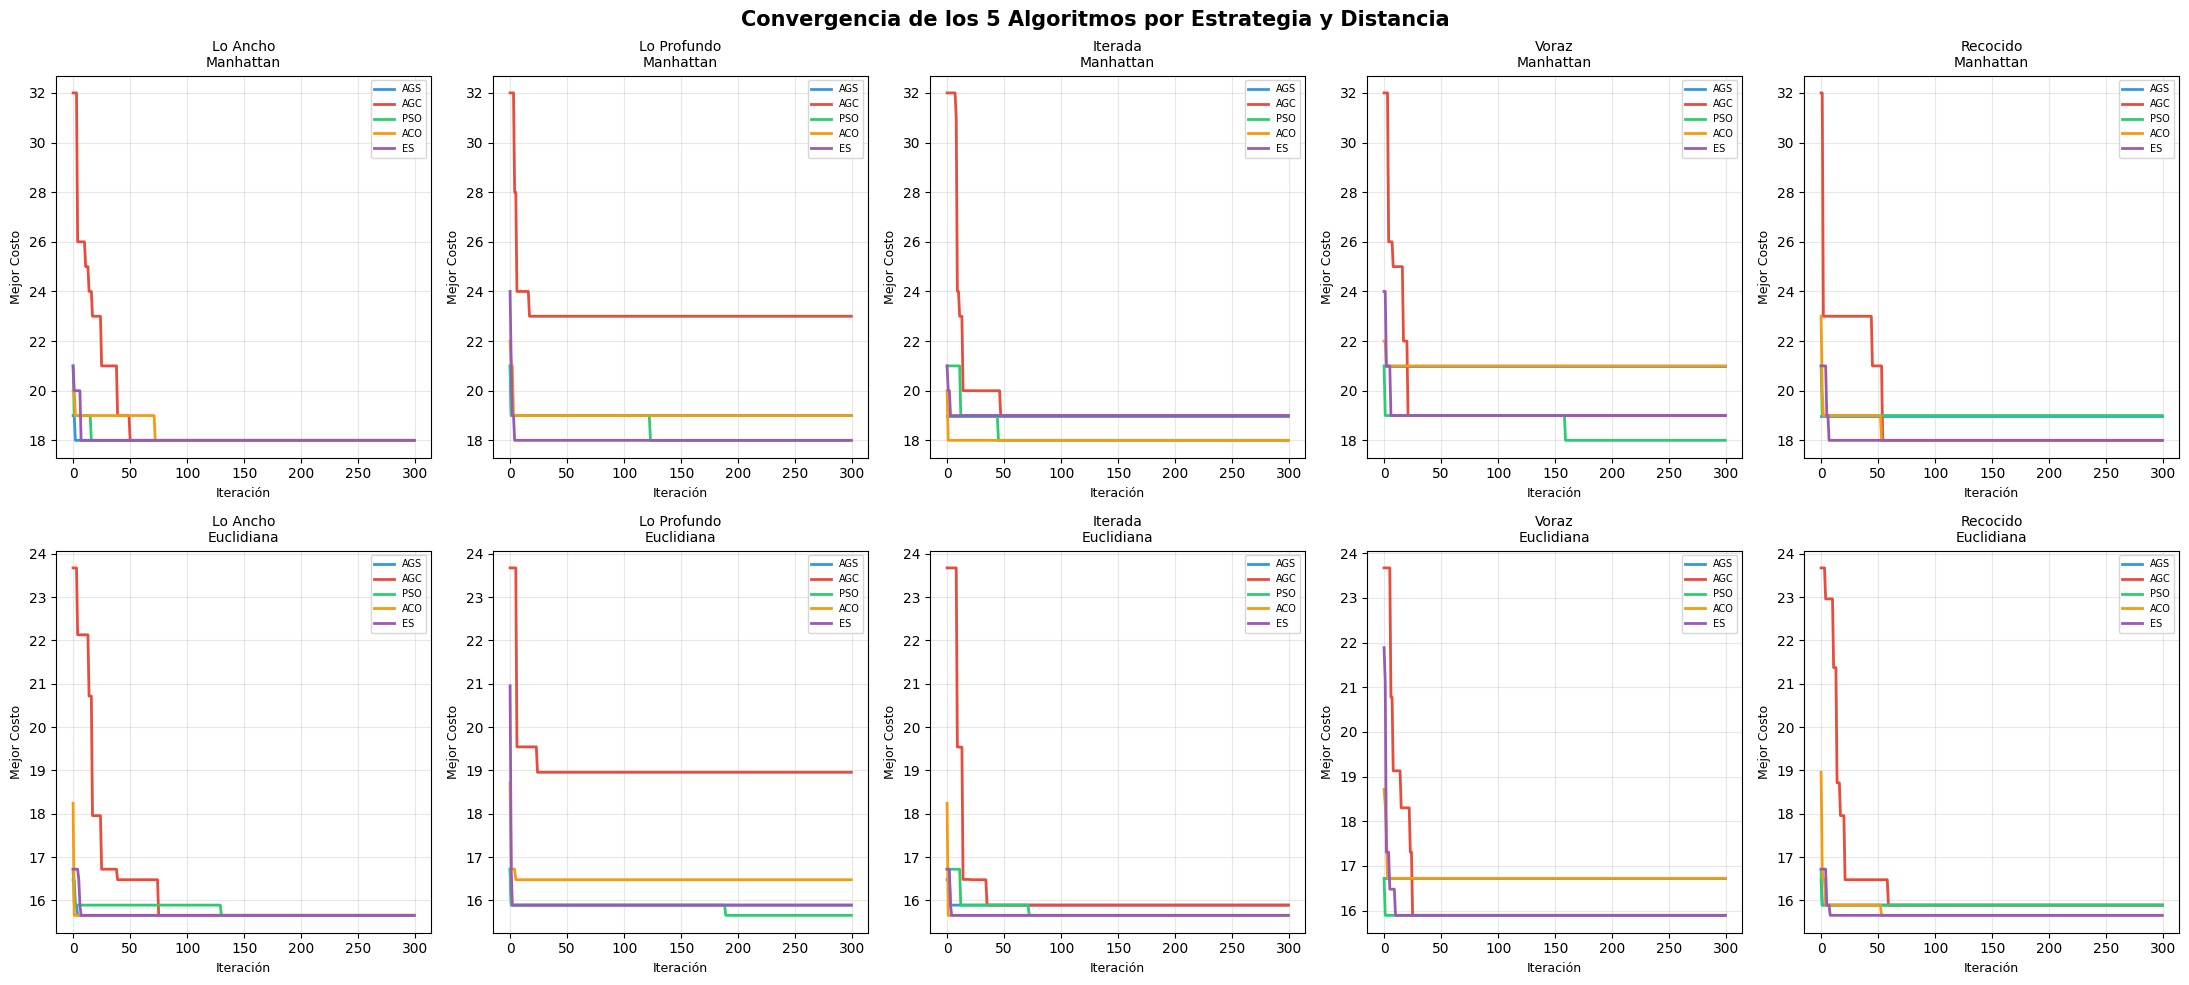

📊 Guardada: 1_convergencia.png


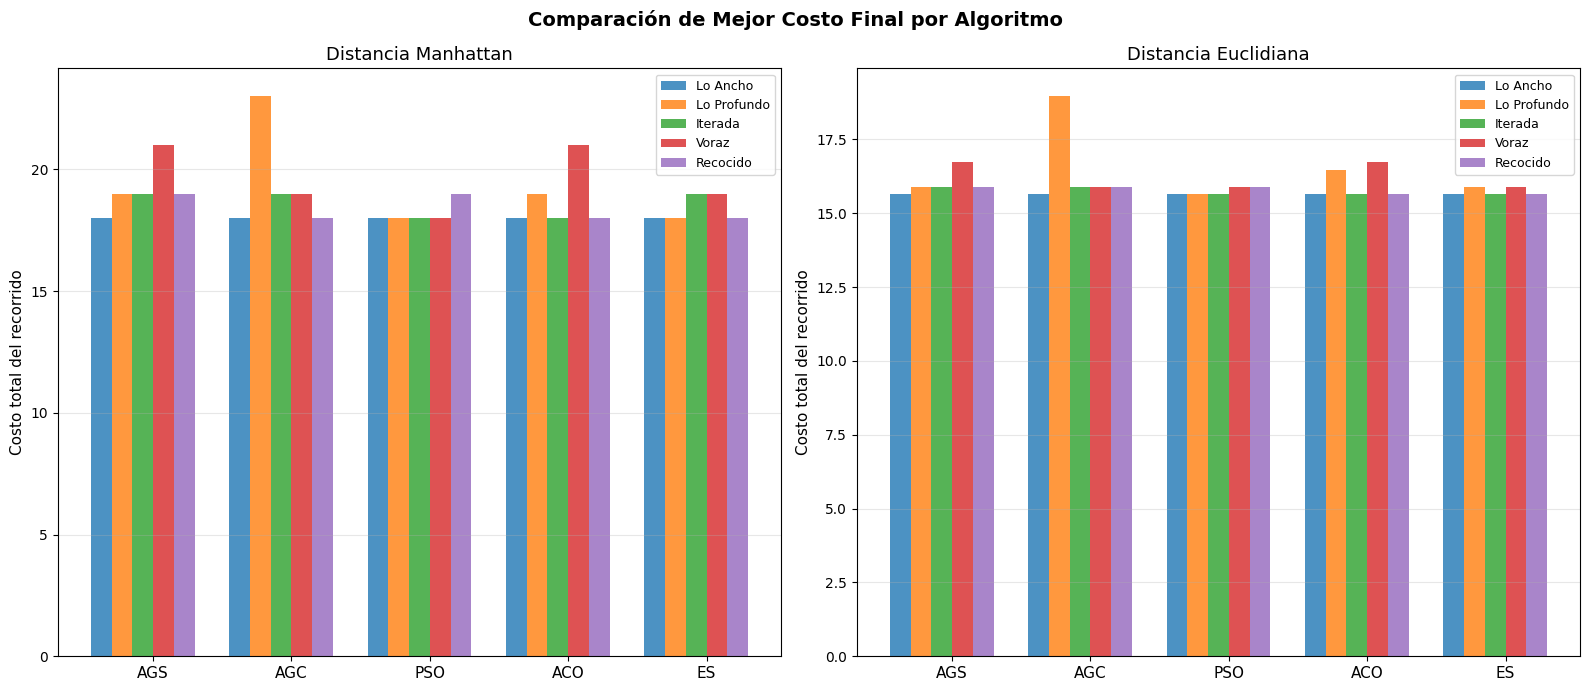

📊 Guardada: 2_comparacion_barras.png


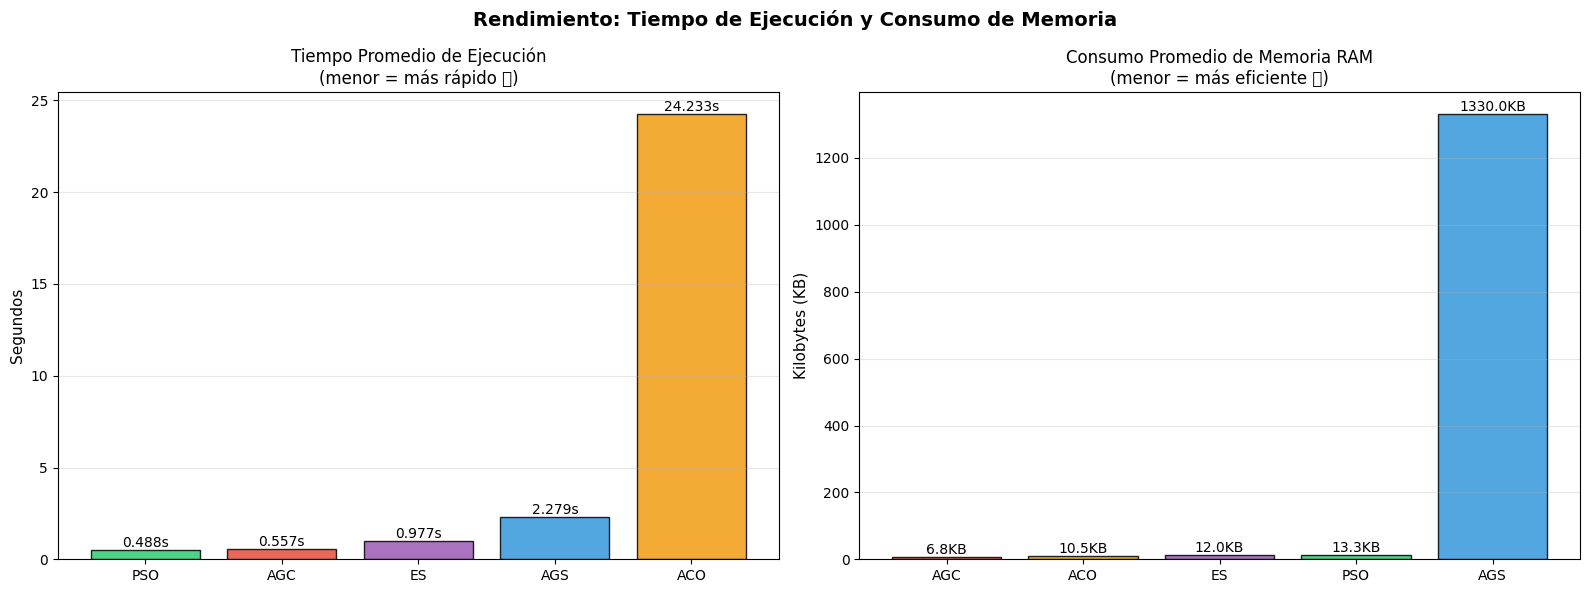

📊 Guardada: 3_tiempo_memoria.png

🧠 RANKING DE MEMORIA (menor a mayor):
  1. AGC: 6.8 KB
  2. ACO: 10.5 KB
  3. ES: 12.0 KB
  4. PSO: 13.3 KB
  5. AGS: 1330.0 KB

⏱️  RANKING DE VELOCIDAD (más rápido a más lento):
  1. PSO: 0.488 s
  2. AGC: 0.557 s
  3. ES: 0.977 s
  4. AGS: 2.279 s
  5. ACO: 24.233 s

🏆 MEJOR SOLUCIÓN GLOBAL:
   Algoritmo : AGS
   Estrategia: ancho
   Distancia : euclidiana
   Costo     : 15.6569


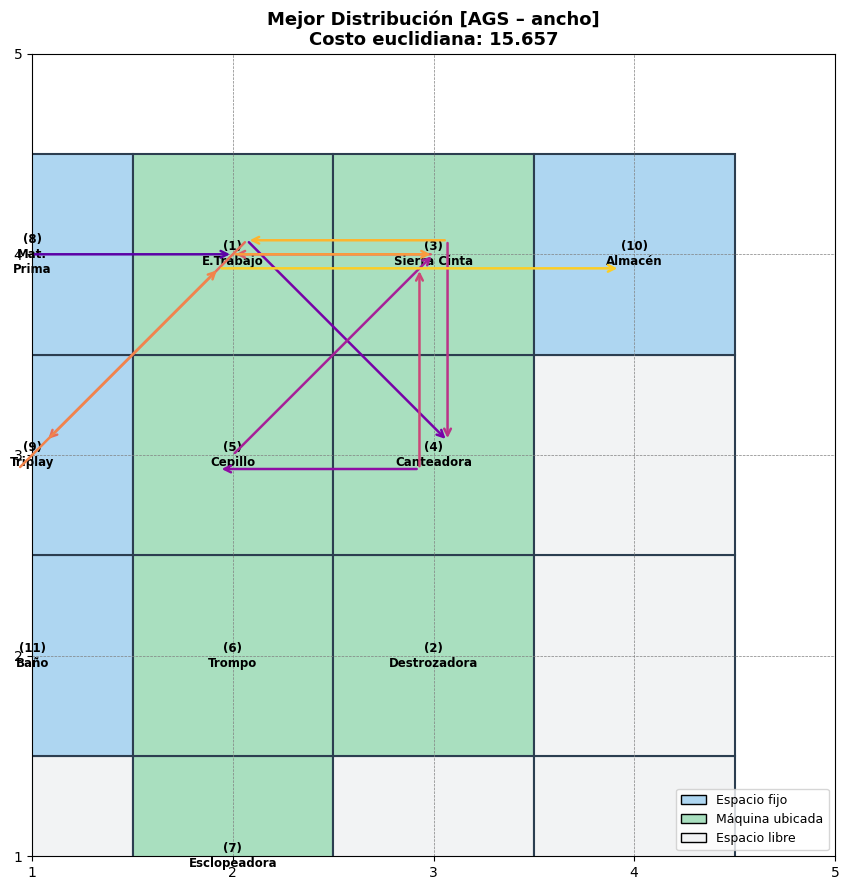

📊 Guardada: 4_mejor_distribucion.png


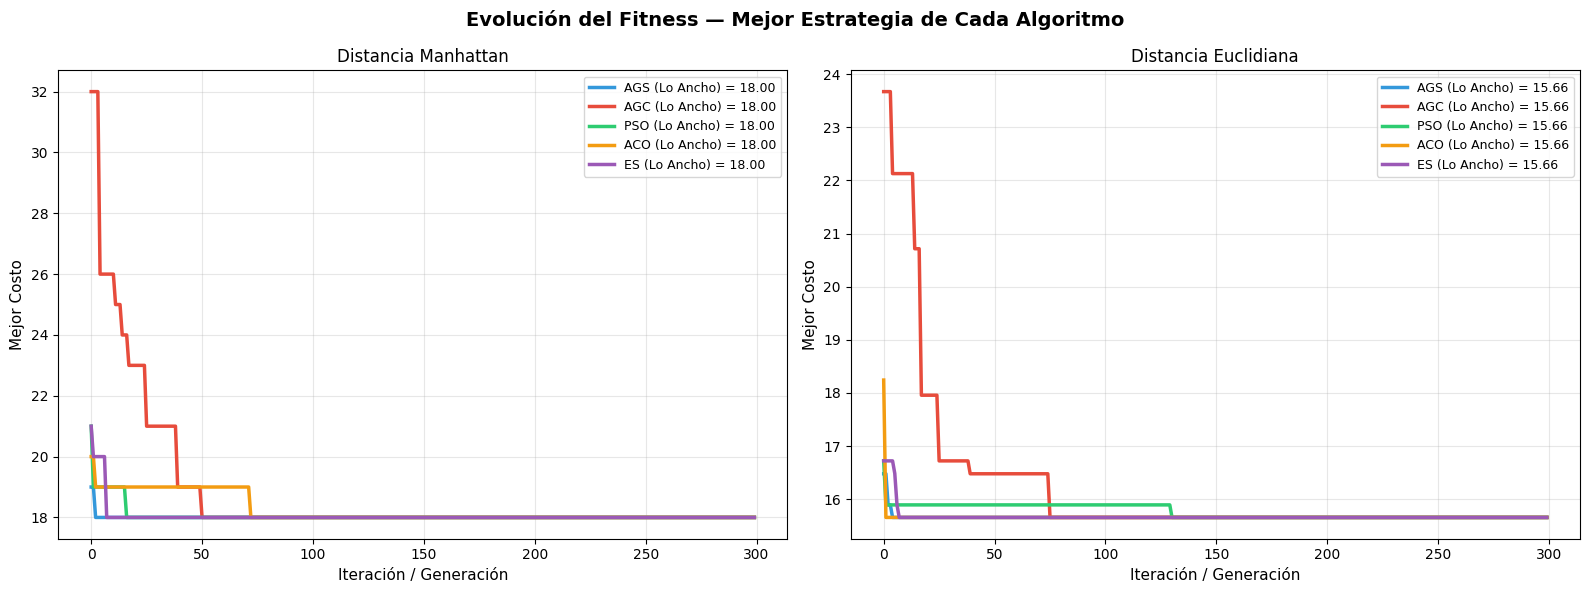

📊 Guardada: 5_evolucion_fitness.png


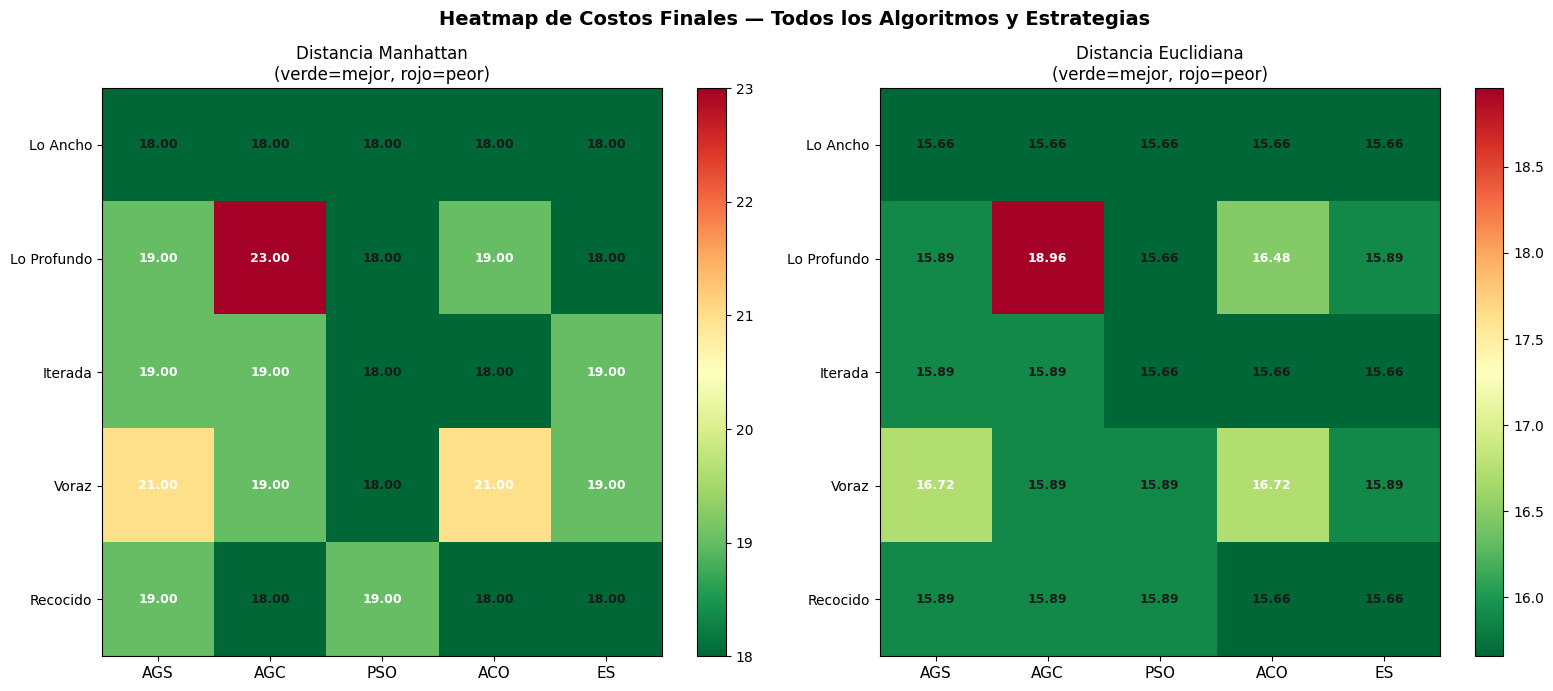

📊 Guardada: 6_heatmap.png


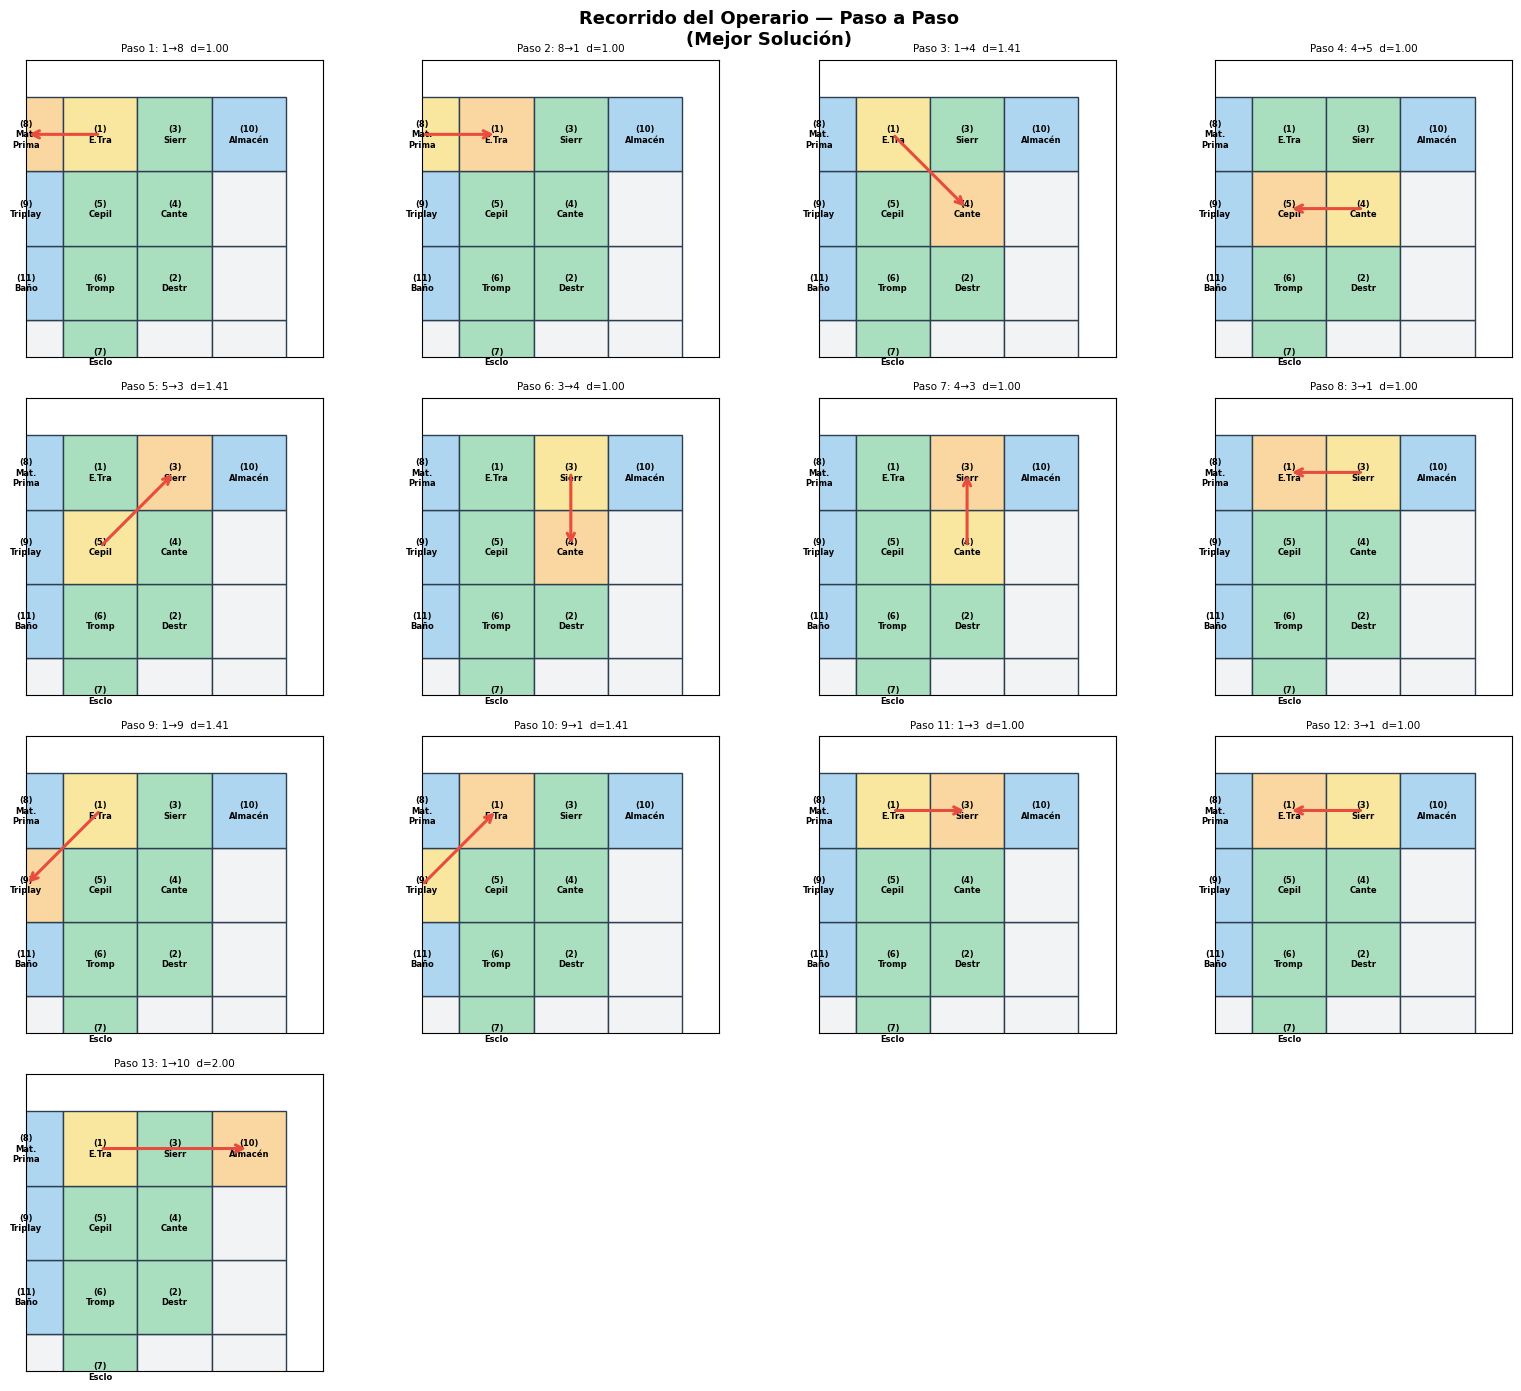

📊 Guardada: 7_recorrido_pasos.png

╔════════════════════════════════════════════════════════════════════╗
║                      ANÁLISIS COMPARATIVO FINAL                    ║
╚════════════════════════════════════════════════════════════════════╝

📌 1. CALIDAD DE SOLUCIÓN (menor costo = mejor)
   Ranking  Algoritmo  Mejor Costo
   --------------------------------
   1        AGS           18.0000 🏆
   2        AGC           18.0000
   3        PSO           18.0000
   4        ACO           18.0000
   5        ES            18.0000

⚡ 2. VELOCIDAD DE CONVERGENCIA (menos iteraciones = más rápido)
   Ranking  Algoritmo  Iteración
   --------------------------------
   1        AGS               2 🏆
   2        ES                7
   3        PSO              16
   4        AGC              50
   5        ACO              72

🧠 3. CONSUMO DE MEMORIA (menor = más eficiente)
   Ranking  Algoritmo  Mem Prom(KB)
   -----------------------------------
   1        AGC                6.8 🏆
   2

In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║     CARPINTERÍA - OPTIMIZACIÓN DE DISTRIBUCIÓN DE MÁQUINAS      ║
# ║                                                                  ║
# ║  Algoritmos implementados:                                       ║
# ║  1. AGS  - Algoritmo Genético Simple                             ║
# ║  2. AGC  - Algoritmo Genético Compacto                           ║
# ║  3. PSO  - Optimización por Enjambre de Partículas               ║
# ║  4. ACO  - Optimización por Colonia de Hormigas                  ║
# ║  5. ES   - Estrategias Evolutivas                                ║
# ║                                                                  ║
# ║  Métricas: Manhattan y Euclidiana                                ║
# ║  Estrategias: Ancho, Profundo, Iterada, Voraz, Recocido          ║
# ║                                                                  ║
# ║  Materia : Inteligencia Artificial                               ║
# ║  Correr en: Google Colab (Python 3)                              ║
# ╚══════════════════════════════════════════════════════════════════╝

# ══════════════════════════════════════════════════════════════════
# CELDA 1 — INSTALACIONES E IMPORTACIONES
# ══════════════════════════════════════════════════════════════════
# Todas las librerías que usaremos vienen incluidas en Google Colab
# No necesitas instalar nada extra

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import random
import math
import copy
import time
import tracemalloc          # Para medir consumo de memoria RAM
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Fijamos una semilla para que los resultados sean reproducibles
# (si cambias este número, los resultados cambiarán un poco)
SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

print("✅ Librerías importadas correctamente.")
print("🚀 Listo para correr en Google Colab")


# ══════════════════════════════════════════════════════════════════
# CELDA 2 — DEFINICIÓN DEL PROBLEMA
# ══════════════════════════════════════════════════════════════════
"""
DESCRIPCIÓN DEL PLANO
─────────────────────
El plano tiene coordenadas X: 1 a 4  y  Y: 1 a 4.
Cada celda mide 2×2 unidades.

ESPACIOS FIJOS (azul) — no se pueden mover:
  (8)  Mat. Prima  → esquina superior izquierda
  (9)  Triplay     → izquierda, fila del medio
  (10) Almacén     → esquina superior derecha
  (11) Baño        → izquierda, fila inferior

MÁQUINAS A UBICAR (7 máquinas):
  1=E.Trabajo    2=Destrozadora  3=Sierra Cinta
  4=Canteadora   5=Cepillo       6=Trompo   7=Esclopeadora

Quedan 12 celdas libres para colocar las 7 máquinas.
"""

# ── Posiciones fijas en el plano (centro de cada celda) ──────────
FIJOS = {
    8:  (1.5, 4.5),   # Mat. Prima
    9:  (1.5, 3.5),   # Triplay
    10: (4.5, 4.5),   # Almacén
    11: (1.5, 2.5),   # Baño
}

# ── Todas las celdas del plano ────────────────────────────────────
CELDAS_TODAS = [(col + 0.5, fila + 0.5)
                for fila in range(1, 5)
                for col in range(1, 5)]

# ── Celdas libres = todas menos las fijas ────────────────────────
CELDAS_LIBRES = [c for c in CELDAS_TODAS if c not in FIJOS.values()]
NUM_LIBRES    = len(CELDAS_LIBRES)   # = 12

# ── Máquinas ──────────────────────────────────────────────────────
MAQUINAS = {
    1: "E.Trabajo",
    2: "Destrozadora",
    3: "Sierra Cinta",
    4: "Canteadora",
    5: "Cepillo",
    6: "Trompo",
    7: "Esclopeadora",
}
NUM_MAQUINAS = len(MAQUINAS)   # = 7

# ── Recorrido del operario (según el PDF) ─────────────────────────
RECORRIDO = [
    (1, 8), (8, 1), (1, 4), (4, 5), (5, 3), (3, 4),
    (4, 3), (3, 1), (1, 9), (9, 1), (1, 3), (3, 1), (1, 10)
]

print(f"✅ Problema definido:")
print(f"   Celdas totales : {len(CELDAS_TODAS)}")
print(f"   Celdas libres  : {NUM_LIBRES}")
print(f"   Máquinas       : {NUM_MAQUINAS}")
print(f"   Pasos recorrido: {len(RECORRIDO)}")


# ══════════════════════════════════════════════════════════════════
# CELDA 3 — FUNCIONES BASE (distancia, fitness, codificación)
# ══════════════════════════════════════════════════════════════════

def coordenada(maquina_id, asignacion):
    """
    Devuelve la posición (x, y) de una máquina en el plano.
    - Si es fija (8,9,10,11) devuelve su posición fija.
    - Si es móvil (1-7) busca en el diccionario de asignación.
    """
    if maquina_id in FIJOS:
        return FIJOS[maquina_id]
    return CELDAS_LIBRES[asignacion[maquina_id]]


def distancia_manhattan(p1, p2):
    """
    Distancia Manhattan: suma de diferencias absolutas.
    Simula movimiento en pasillos (solo horizontal/vertical).
    """
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])


def distancia_euclidiana(p1, p2):
    """
    Distancia Euclidiana: línea recta entre dos puntos.
    Fórmula: √((x2-x1)² + (y2-y1)²)
    """
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)


def calcular_costo(asignacion, tipo_distancia='manhattan'):
    """
    Calcula el costo total del recorrido del operario.

    Parámetros:
        asignacion     : dict {id_maquina: idx_celda_libre}
        tipo_distancia : 'manhattan' o 'euclidiana'

    Retorna:
        float — suma de distancias de todos los pasos
    """
    dist_fn = (distancia_manhattan if tipo_distancia == 'manhattan'
               else distancia_euclidiana)
    return sum(dist_fn(coordenada(o, asignacion), coordenada(d, asignacion))
               for o, d in RECORRIDO)


def genes_a_asignacion(genes):
    """
    Convierte una lista de 7 índices de celda en un diccionario.
    genes[i] = índice de celda para la máquina (i+1)
    Ejemplo: [3,7,1,10,5,8,2] → {1:3, 2:7, 3:1, 4:10, 5:5, 6:8, 7:2}
    """
    return {maq: genes[i] for i, maq in enumerate(MAQUINAS)}


def individuo_aleatorio():
    """
    Genera una solución aleatoria válida.
    Es una permutación parcial: 7 índices distintos de los 12 disponibles.
    """
    celdas = list(range(NUM_LIBRES))
    random.shuffle(celdas)
    return celdas[:NUM_MAQUINAS]


print("✅ Funciones base definidas.")

# ── Prueba rápida ─────────────────────────────────────────────────
g = individuo_aleatorio()
a = genes_a_asignacion(g)
print(f"\n   Prueba rápida:")
print(f"   Genes     : {g}")
print(f"   Costo Manh: {calcular_costo(a, 'manhattan'):.3f}")
print(f"   Costo Eucl: {calcular_costo(a, 'euclidiana'):.3f}")


# ══════════════════════════════════════════════════════════════════
# CELDA 4 — ALGORITMO GENÉTICO SIMPLE (AGS)
# ══════════════════════════════════════════════════════════════════
"""
¿QUÉ ES EL AGS?
───────────────
Inspirado en la evolución biológica de Darwin.
Mantiene una POBLACIÓN de 50 soluciones que evolucionan
generación a generación mediante selección, cruce y mutación.

Analogía: 50 chefs con diferentes recetas. Los mejores
mezclan sus recetas para crear recetas hijas cada ronda.
"""

def seleccion_torneo(poblacion, costos, k=3):
    """
    Selección por torneo: elige k individuos al azar
    y devuelve el de menor costo (el mejor).
    """
    candidatos = random.sample(range(len(poblacion)), k)
    ganador    = min(candidatos, key=lambda i: costos[i])
    return copy.copy(poblacion[ganador])


def cruce_ox(padre1, padre2):
    """
    Cruce OX (Order Crossover): combina dos padres
    preservando el orden de genes (importante para permutaciones).

    Pasos:
    1. Copia un segmento del padre1 al hijo.
    2. Rellena el resto con genes del padre2 en orden.
    """
    n    = len(padre1)
    a, b = sorted(random.sample(range(n), 2))
    hijo = [None] * n
    hijo[a:b+1] = padre1[a:b+1]
    restantes = [g for g in padre2 if g not in hijo]
    j = 0
    for i in range(n):
        if hijo[i] is None:
            hijo[i] = restantes[j]
            j += 1
    return hijo


def mutacion_swap(individuo, tasa=0.2):
    """
    Mutación por intercambio: con probabilidad 'tasa',
    intercambia dos genes al azar. Mantiene validez del vector.
    """
    ind = copy.copy(individuo)
    if random.random() < tasa:
        i, j = random.sample(range(len(ind)), 2)
        ind[i], ind[j] = ind[j], ind[i]
    return ind


def ags(tam_pob=50, generaciones=300, tasa_mut=0.2, elitismo=2,
        tipo_distancia='manhattan', estrategia='ancho'):
    """
    Algoritmo Genético Simple completo.

    Estrategias:
      ancho    → mucha diversidad (población grande)
      profundo → mucha explotación (elitismo alto)
      iterada  → reinicios periódicos
      voraz    → siempre los mejores, sin exploración
      recocido → acepta peores soluciones al inicio
    """
    # Ajustar parámetros según estrategia
    if estrategia == 'ancho':
        tam_pob, tasa_mut, elitismo = 80, 0.3, 1
    elif estrategia == 'profundo':
        tam_pob, tasa_mut, elitismo = 30, 0.1, 5
    elif estrategia == 'voraz':
        tam_pob, tasa_mut, elitismo = 20, 0.05, tam_pob // 2
    elif estrategia == 'iterada':
        tam_pob = 50

    # Crear población inicial aleatoria
    poblacion = [individuo_aleatorio() for _ in range(tam_pob)]

    mejor_genes = None
    mejor_costo = float('inf')
    historial   = []

    temperatura  = 1.0       # Para recocido simulado
    enfriamiento = 0.995

    # Períodos de reinicio para estrategia iterada
    periodo_reinicio = generaciones // 4 if estrategia == 'iterada' else generaciones + 1

    for gen in range(generaciones):

        # Reinicio parcial en estrategia iterada
        if estrategia == 'iterada' and gen > 0 and gen % periodo_reinicio == 0:
            for i in range(tam_pob // 4):
                poblacion[-(i+1)] = individuo_aleatorio()

        # Calcular costos de toda la población
        costos = [calcular_costo(genes_a_asignacion(ind), tipo_distancia)
                  for ind in poblacion]

        # Actualizar mejor solución encontrada
        idx_mejor = min(range(tam_pob), key=lambda i: costos[i])
        if costos[idx_mejor] < mejor_costo:
            mejor_costo = costos[idx_mejor]
            mejor_genes = copy.copy(poblacion[idx_mejor])
        historial.append(mejor_costo)

        # Crear nueva generación
        nueva_pob = []

        # Elitismo: los mejores pasan directo
        idx_ord = sorted(range(tam_pob), key=lambda i: costos[i])
        for i in range(min(elitismo, tam_pob)):
            nueva_pob.append(copy.copy(poblacion[idx_ord[i]]))

        # Completar con hijos
        while len(nueva_pob) < tam_pob:
            if estrategia == 'voraz':
                padre = seleccion_torneo(poblacion, costos, k=5)
                hijo  = mutacion_swap(padre, tasa_mut)
            elif estrategia == 'recocido':
                p1   = seleccion_torneo(poblacion, costos)
                p2   = seleccion_torneo(poblacion, costos)
                hijo = cruce_ox(p1, p2)
                hijo = mutacion_swap(hijo, tasa_mut)
                # Aceptar solución peor con probabilidad e^(-Δ/T)
                c_hijo = calcular_costo(genes_a_asignacion(hijo), tipo_distancia)
                c_p1   = calcular_costo(genes_a_asignacion(p1),   tipo_distancia)
                delta  = c_hijo - c_p1
                if delta >= 0 and random.random() >= math.exp(-delta / (temperatura + 1e-9)):
                    hijo = copy.copy(p1)
                temperatura *= enfriamiento
            else:
                p1   = seleccion_torneo(poblacion, costos)
                p2   = seleccion_torneo(poblacion, costos)
                hijo = cruce_ox(p1, p2)
                hijo = mutacion_swap(hijo, tasa_mut)
            nueva_pob.append(hijo)

        poblacion = nueva_pob

    return mejor_genes, mejor_costo, historial


print("✅ AGS definido.")


# ══════════════════════════════════════════════════════════════════
# CELDA 5 — ALGORITMO GENÉTICO COMPACTO (AGC)
# ══════════════════════════════════════════════════════════════════
"""
¿QUÉ ES EL AGC?
───────────────
En lugar de guardar 50 individuos, mantiene una TABLA DE
PROBABILIDADES. Cada celda de la tabla dice qué tan probable
es que una máquina vaya en cierta posición.

Analogía: Un cuaderno de notas donde se apunta qué combinación
ha funcionado mejor. Solo guarda experiencia, no soluciones.
"""

def muestrear_cga(prob_matrix):
    """
    Construye un vector válido sorteando celda por celda,
    usando las probabilidades de la tabla.
    Una vez elegida una celda, se tacha para las siguientes máquinas.
    """
    usadas = set()
    genes  = []
    for i in range(NUM_MAQUINAS):
        probs = prob_matrix[i].copy()
        for u in usadas:
            probs[u] = 0.0    # Tachar celdas ya usadas
        total = probs.sum()
        if total == 0:
            disponibles = [c for c in range(NUM_LIBRES) if c not in usadas]
            celda = random.choice(disponibles)
        else:
            probs /= total
            celda = np.random.choice(NUM_LIBRES, p=probs)
        genes.append(int(celda))
        usadas.add(int(celda))
    return genes


def actualizar_cga(prob_matrix, winner, loser, N, tasa=None):
    """
    Actualiza la tabla de probabilidades:
    - La celda del ganador SUBE en probabilidad.
    - La celda del perdedor BAJA en probabilidad.
    - Solo se actualiza donde ganador y perdedor difieren.

    N controla qué tan rápido aprende:
    - N grande = aprende despacio (más exploración)
    - N pequeño = aprende rápido (más explotación)
    """
    lr = tasa if tasa else 1.0 / N
    for i in range(NUM_MAQUINAS):
        if winner[i] != loser[i]:
            prob_matrix[i][winner[i]] = min(1.0, prob_matrix[i][winner[i]] + lr)
            prob_matrix[i][loser[i]]  = max(0.0, prob_matrix[i][loser[i]]  - lr)
    return prob_matrix


def agc(iteraciones=300, N=50, tipo_distancia='manhattan', estrategia='ancho'):
    """
    Algoritmo Genético Compacto completo.
    Genera dos vectores por ronda, compara y actualiza la tabla.
    """
    if estrategia == 'ancho':
        N = max(N, 100)
    elif estrategia == 'profundo':
        N = max(10, N // 5)

    # Tabla inicial: probabilidades uniformes (nadie sabe nada)
    prob_matrix = np.ones((NUM_MAQUINAS, NUM_LIBRES)) / NUM_LIBRES

    mejor_genes = None
    mejor_costo = float('inf')
    historial   = []

    temperatura  = 1.0
    enfriamiento = 0.99
    periodo_reinicio = iteraciones // 4 if estrategia == 'iterada' else iteraciones + 1

    for it in range(iteraciones):

        # Reinicio periódico para estrategia iterada
        if estrategia == 'iterada' and it > 0 and it % periodo_reinicio == 0:
            uniforme    = np.ones((NUM_MAQUINAS, NUM_LIBRES)) / NUM_LIBRES
            prob_matrix = 0.5 * prob_matrix + 0.5 * uniforme

        # Sortear DOS vectores usando la tabla de probabilidades
        a = muestrear_cga(prob_matrix)
        b = muestrear_cga(prob_matrix)

        costo_a = calcular_costo(genes_a_asignacion(a), tipo_distancia)
        costo_b = calcular_costo(genes_a_asignacion(b), tipo_distancia)

        # El de menor costo gana
        costo_it = min(costo_a, costo_b)
        if costo_it < mejor_costo:
            mejor_costo = costo_it
            mejor_genes = copy.copy(a if costo_a <= costo_b else b)
        historial.append(mejor_costo)

        winner = a if costo_a <= costo_b else b
        loser  = b if costo_a <= costo_b else a

        # Recocido: a veces acepta el perdedor
        if estrategia == 'recocido':
            delta = abs(costo_a - costo_b)
            if random.random() < math.exp(-delta / (temperatura + 1e-9)):
                winner, loser = loser, winner
            temperatura *= enfriamiento

        # Voraz: siempre usar el mejor conocido como referencia
        if estrategia == 'voraz' and mejor_genes is not None:
            winner = mejor_genes

        tasa = (2.0 / N) if estrategia in ('profundo', 'iterada') else None
        prob_matrix = actualizar_cga(prob_matrix, winner, loser, N, tasa)

    return mejor_genes, mejor_costo, historial


print("✅ AGC definido.")


# ══════════════════════════════════════════════════════════════════
# CELDA 6 — PSO: OPTIMIZACIÓN POR ENJAMBRE DE PARTÍCULAS
# ══════════════════════════════════════════════════════════════════
"""
¿QUÉ ES EL PSO?
───────────────
Inspirado en el vuelo de bandadas de pájaros.
Cada PARTÍCULA es una solución que "vuela" por el espacio
de soluciones guiada por:
  1. Su propia mejor posición histórica (instinto personal)
  2. La mejor posición encontrada por todo el enjambre (social)

Analogía: 30 pájaros buscando comida. Cada uno recuerda
dónde encontró más comida antes, y también sabe dónde
encontró más comida el mejor pájaro del grupo.
"""

def pso(n_particulas=30, iteraciones=300,
        tipo_distancia='manhattan', estrategia='ancho'):
    """
    PSO adaptado para permutaciones discretas.

    Como nuestro problema es discreto (índices de celdas),
    adaptamos el PSO usando perturbaciones controladas
    en lugar de velocidades continuas.

    w  = inercia     (qué tanto mantiene su dirección actual)
    c1 = cognitivo   (atracción hacia su mejor personal)
    c2 = social      (atracción hacia el mejor global)
    """
    # Ajustar parámetros según estrategia
    if estrategia == 'ancho':
        w, c1, c2 = 0.9, 1.0, 1.5
    elif estrategia == 'profundo':
        w, c1, c2 = 0.4, 2.0, 1.0
    elif estrategia == 'voraz':
        w, c1, c2 = 0.3, 0.5, 2.5
    elif estrategia == 'recocido':
        w, c1, c2 = 0.7, 1.5, 1.5
    else:  # iterada
        w, c1, c2 = 0.6, 1.5, 1.5

    # Inicializar enjambre: cada partícula es un vector aleatorio
    particulas      = [individuo_aleatorio() for _ in range(n_particulas)]
    mejor_personal  = copy.deepcopy(particulas)  # Mejor posición de cada partícula
    costos_personal = [calcular_costo(genes_a_asignacion(p), tipo_distancia)
                       for p in particulas]

    # Mejor global del enjambre
    idx_mejor_global = min(range(n_particulas), key=lambda i: costos_personal[i])
    mejor_global     = copy.copy(particulas[idx_mejor_global])
    mejor_costo      = costos_personal[idx_mejor_global]
    historial        = []

    temperatura = 1.0  # Para recocido

    for it in range(iteraciones):
        for i in range(n_particulas):

            nueva_pos = copy.copy(particulas[i])

            # ── Componente COGNITIVA: moverse hacia su mejor personal ──
            # Usamos cruce OX parcial: tomamos 1 gen del mejor personal
            # y lo insertamos en nueva_pos mediante un swap seguro.
            if random.random() < c1 / (c1 + c2):
                for idx in range(NUM_MAQUINAS):
                    valor_deseado = mejor_personal[i][idx]
                    if nueva_pos[idx] != valor_deseado:
                        # Solo hacemos swap si el valor existe en nueva_pos
                        if valor_deseado in nueva_pos:
                            j = nueva_pos.index(valor_deseado)
                            nueva_pos[idx], nueva_pos[j] = nueva_pos[j], nueva_pos[idx]
                        break

            # ── Componente SOCIAL: moverse hacia el mejor global ──────
            # Igual que cognitiva pero guiada por el mejor del enjambre.
            if random.random() < c2 / (c1 + c2):
                for idx in range(NUM_MAQUINAS):
                    valor_deseado = mejor_global[idx]
                    if nueva_pos[idx] != valor_deseado:
                        # Solo hacemos swap si el valor existe en nueva_pos
                        if valor_deseado in nueva_pos:
                            j = nueva_pos.index(valor_deseado)
                            nueva_pos[idx], nueva_pos[j] = nueva_pos[j], nueva_pos[idx]
                        break

            # ── Inercia: mutación aleatoria controlada ────────────────
            if random.random() < w * 0.3:
                nueva_pos = mutacion_swap(nueva_pos, 1.0)

            # Recocido: reinicio parcial del enjambre
            if estrategia == 'recocido':
                costo_actual = calcular_costo(genes_a_asignacion(particulas[i]),
                                              tipo_distancia)
                costo_nueva  = calcular_costo(genes_a_asignacion(nueva_pos),
                                              tipo_distancia)
                delta = costo_nueva - costo_actual
                if delta < 0 or random.random() < math.exp(-delta / (temperatura + 1e-9)):
                    particulas[i] = nueva_pos
            else:
                particulas[i] = nueva_pos

            # Actualizar mejor personal de esta partícula
            costo_nueva = calcular_costo(genes_a_asignacion(particulas[i]),
                                         tipo_distancia)
            if costo_nueva < costos_personal[i]:
                costos_personal[i] = costo_nueva
                mejor_personal[i]  = copy.copy(particulas[i])

                # Actualizar mejor global del enjambre
                if costo_nueva < mejor_costo:
                    mejor_costo  = costo_nueva
                    mejor_global = copy.copy(particulas[i])

        historial.append(mejor_costo)
        temperatura *= 0.995

        # Estrategia iterada: reiniciar partículas malas periódicamente
        if estrategia == 'iterada' and it > 0 and it % (iteraciones // 4) == 0:
            idx_peores = sorted(range(n_particulas),
                                key=lambda i: costos_personal[i],
                                reverse=True)[:n_particulas // 4]
            for idx in idx_peores:
                particulas[idx]      = individuo_aleatorio()
                costos_personal[idx] = calcular_costo(
                    genes_a_asignacion(particulas[idx]), tipo_distancia)
                mejor_personal[idx]  = copy.copy(particulas[idx])

    return mejor_global, mejor_costo, historial


print("✅ PSO definido.")


# ══════════════════════════════════════════════════════════════════
# CELDA 7 — ACO: OPTIMIZACIÓN POR COLONIA DE HORMIGAS
# ══════════════════════════════════════════════════════════════════
"""
¿QUÉ ES EL ACO?
───────────────
Inspirado en cómo las hormigas encuentran el camino más corto
usando rastros de FEROMONAS.

Las hormigas virtuales construyen soluciones paso a paso.
Las buenas soluciones dejan más feromonas.
Las feromonas se evaporan con el tiempo (para evitar estancamiento).

Analogía: Hormigas dejando rastros en el suelo. El camino
más transitado (con más feromona) atrae a más hormigas,
que a su vez refuerzan ese camino.
"""

def aco(n_hormigas=30, iteraciones=300, evaporacion=0.1,
        alpha=1.0, beta=2.0, tipo_distancia='manhattan',
        estrategia='ancho'):
    """
    ACO adaptado para el problema de asignación de máquinas.

    alpha      : importancia de las feromonas
    beta       : importancia de la heurística (distancia al centro)
    evaporacion: qué tan rápido se evaporan las feromonas (0-1)

    La heurística local = qué tan "céntrica" es una celda
    (las celdas centrales suelen ser mejores porque minimizan
    distancias en promedio).
    """
    # Ajustar parámetros según estrategia
    if estrategia == 'ancho':
        alpha, beta, evaporacion = 0.5, 2.0, 0.05
    elif estrategia == 'profundo':
        alpha, beta, evaporacion = 2.0, 1.0, 0.3
    elif estrategia == 'voraz':
        alpha, beta, evaporacion = 3.0, 0.5, 0.5
    elif estrategia == 'recocido':
        alpha, beta, evaporacion = 1.0, 1.5, 0.1
    elif estrategia == 'iterada':
        alpha, beta, evaporacion = 1.0, 2.0, 0.15

    # Tabla de feromonas inicial: uniforme
    # feromonas[posicion][celda] = nivel de feromona
    feromonas = np.ones((NUM_MAQUINAS, NUM_LIBRES))

    # Heurística: valorar celdas más centrales del plano
    # (centro del plano es (3, 3))
    centro = (3.0, 3.0)
    heuristica = np.array([
        1.0 / (1.0 + distancia_euclidiana(CELDAS_LIBRES[j], centro))
        for j in range(NUM_LIBRES)
    ])

    mejor_genes = None
    mejor_costo = float('inf')
    historial   = []

    temperatura = 1.0  # Para recocido

    for it in range(iteraciones):

        soluciones = []
        costos_it  = []

        # Cada hormiga construye su solución
        for h in range(n_hormigas):
            usadas = set()
            genes  = []

            for pos in range(NUM_MAQUINAS):
                # Calcular probabilidad de elegir cada celda libre
                probs = np.zeros(NUM_LIBRES)
                for j in range(NUM_LIBRES):
                    if j not in usadas:
                        # Probabilidad = feromona^alpha × heurística^beta
                        probs[j] = (feromonas[pos][j] ** alpha) * (heuristica[j] ** beta)

                total = probs.sum()
                if total == 0:
                    disponibles = [j for j in range(NUM_LIBRES) if j not in usadas]
                    celda = random.choice(disponibles)
                else:
                    probs /= total
                    celda = np.random.choice(NUM_LIBRES, p=probs)

                genes.append(int(celda))
                usadas.add(int(celda))

            soluciones.append(genes)
            costos_it.append(calcular_costo(genes_a_asignacion(genes),
                                            tipo_distancia))

        # Actualizar mejor solución
        idx_mejor_it = min(range(n_hormigas), key=lambda i: costos_it[i])
        if costos_it[idx_mejor_it] < mejor_costo:
            mejor_costo = costos_it[idx_mejor_it]
            mejor_genes = copy.copy(soluciones[idx_mejor_it])
        historial.append(mejor_costo)

        # ── Evaporar feromonas ────────────────────────────────────
        feromonas *= (1 - evaporacion)
        feromonas  = np.maximum(feromonas, 0.01)  # Mínimo para no llegar a 0

        # ── Depositar nuevas feromonas ────────────────────────────
        for h in range(n_hormigas):
            deposito = 1.0 / (1.0 + costos_it[h])  # Mejor solución = más feromona
            for pos, celda in enumerate(soluciones[h]):
                feromonas[pos][celda] += deposito

        # Recocido: reiniciar feromonas parcialmente
        if estrategia == 'recocido':
            feromonas = feromonas * temperatura + (1 - temperatura)
            temperatura *= 0.99

        # Iterada: reiniciar tabla de feromonas periódicamente
        if estrategia == 'iterada' and it > 0 and it % (iteraciones // 4) == 0:
            feromonas = 0.5 * feromonas + 0.5 * np.ones((NUM_MAQUINAS, NUM_LIBRES))

    return mejor_genes, mejor_costo, historial


print("✅ ACO definido.")


# ══════════════════════════════════════════════════════════════════
# CELDA 8 — ES: ESTRATEGIAS EVOLUTIVAS
# ══════════════════════════════════════════════════════════════════
"""
¿QUÉ SON LAS ESTRATEGIAS EVOLUTIVAS (ES)?
──────────────────────────────────────────
Son una variante de los algoritmos genéticos, pero con un
enfoque diferente:

- En el AGS el protagonista es el CRUCE entre individuos.
- En las ES el protagonista es la MUTACIÓN adaptativa.

Las ES adaptan automáticamente la INTENSIDAD de la mutación
conforme el algoritmo avanza. Si la mutación está produciendo
mejoras, se hace más intensa. Si no mejora, se reduce.

Esto se llama la "regla del 1/5": si más del 20% de las
mutaciones mejoran la solución, aumentar la intensidad.
Si menos del 20% mejoran, reducirla.

Analogía: Como aprender a cocinar. Al principio pruebas
cambios grandes (más sal, menos azúcar). Cuando ya casi
lo tienes perfecto, haces ajustes muy pequeños y precisos.
"""

def es(mu=20, lambda_=60, generaciones=300,
       tipo_distancia='manhattan', estrategia='ancho'):
    """
    Estrategia Evolutiva (mu, lambda).

    mu     : tamaño de la población de padres
    lambda_: número de hijos generados por generación
    (lambda_ > mu siempre, generalmente lambda_ = 3*mu)

    La mutación tiene una FUERZA que se adapta automáticamente
    usando la regla del 1/5 de Rechenberg.
    """
    # Ajustar parámetros según estrategia
    if estrategia == 'ancho':
        mu, lambda_ = 15, 60
    elif estrategia == 'profundo':
        mu, lambda_ = 5, 20
    elif estrategia == 'voraz':
        mu, lambda_ = 3, 15
    elif estrategia == 'iterada':
        mu, lambda_ = 10, 40

    # Crear población inicial
    poblacion = [individuo_aleatorio() for _ in range(mu)]
    costos    = [calcular_costo(genes_a_asignacion(p), tipo_distancia)
                 for p in poblacion]

    mejor_genes = copy.copy(poblacion[min(range(mu), key=lambda i: costos[i])])
    mejor_costo = min(costos)
    historial   = [mejor_costo]

    # Fuerza de mutación inicial (número de swaps por mutación)
    fuerza_mutacion = 2
    # Historial de éxitos para la regla del 1/5
    exitos_recientes = deque(maxlen=20)

    temperatura = 1.0  # Para recocido

    for gen in range(1, generaciones):

        hijos       = []
        costos_hijo = []
        exitos_gen  = 0

        # Generar lambda_ hijos
        for _ in range(lambda_):
            # Elegir padre al azar de los mejores
            padre = copy.copy(random.choice(poblacion))

            # Mutación: aplicar 'fuerza_mutacion' swaps
            hijo = copy.copy(padre)
            for _ in range(fuerza_mutacion):
                hijo = mutacion_swap(hijo, tasa=1.0)

            costo_hijo  = calcular_costo(genes_a_asignacion(hijo), tipo_distancia)
            costo_padre = calcular_costo(genes_a_asignacion(padre), tipo_distancia)

            # Recocido: aceptar con probabilidad si es peor
            if estrategia == 'recocido':
                delta = costo_hijo - costo_padre
                if delta < 0 or random.random() < math.exp(-delta / (temperatura + 1e-9)):
                    hijos.append(hijo)
                    costos_hijo.append(costo_hijo)
                    if costo_hijo < costo_padre:
                        exitos_gen += 1
            else:
                hijos.append(hijo)
                costos_hijo.append(costo_hijo)
                if costo_hijo < costo_padre:
                    exitos_gen += 1

        if not hijos:
            historial.append(mejor_costo)
            continue

        temperatura *= 0.995
        exitos_recientes.append(exitos_gen / lambda_)

        # ── Regla del 1/5: adaptar la fuerza de mutación ─────────
        tasa_exito = sum(exitos_recientes) / len(exitos_recientes) if exitos_recientes else 0
        if tasa_exito > 0.2:
            fuerza_mutacion = min(fuerza_mutacion + 1, NUM_MAQUINAS - 1)
        elif tasa_exito < 0.2 and fuerza_mutacion > 1:
            fuerza_mutacion = max(fuerza_mutacion - 1, 1)

        # Selección: los mu mejores hijos sobreviven (selección (mu, lambda))
        idx_ord = sorted(range(len(hijos)), key=lambda i: costos_hijo[i])
        poblacion = [hijos[i]       for i in idx_ord[:mu]]
        costos    = [costos_hijo[i] for i in idx_ord[:mu]]

        # Estrategia iterada: reiniciar parte de la población
        if estrategia == 'iterada' and gen % (generaciones // 4) == 0:
            for i in range(mu // 4):
                poblacion[-(i+1)] = individuo_aleatorio()
                costos[-(i+1)]    = calcular_costo(
                    genes_a_asignacion(poblacion[-(i+1)]), tipo_distancia)

        # Actualizar mejor solución global
        if costos[0] < mejor_costo:
            mejor_costo = costos[0]
            mejor_genes = copy.copy(poblacion[0])

        historial.append(mejor_costo)

    return mejor_genes, mejor_costo, historial


print("✅ ES (Estrategias Evolutivas) definida.")


# ══════════════════════════════════════════════════════════════════
# CELDA 9 — EJECUCIÓN DE TODOS LOS EXPERIMENTOS CON MEDICIÓN
# ══════════════════════════════════════════════════════════════════
"""
Corremos los 5 algoritmos × 5 estrategias × 2 distancias.
Para cada combinación medimos:
  • Tiempo de ejecución (segundos)
  • Memoria RAM usada (KB)
  • Mejor costo encontrado
"""

ALGORITMOS  = ['AGS', 'AGC', 'PSO', 'ACO', 'ES']
ESTRATEGIAS = ['ancho', 'profundo', 'iterada', 'voraz', 'recocido']
DISTANCIAS  = ['manhattan', 'euclidiana']
ITERS       = 300   # Iteraciones/generaciones para todos

# Diccionario de funciones por algoritmo
FUNCIONES = {
    'AGS': lambda dist, est: ags(generaciones=ITERS, tipo_distancia=dist, estrategia=est),
    'AGC': lambda dist, est: agc(iteraciones=ITERS,  tipo_distancia=dist, estrategia=est),
    'PSO': lambda dist, est: pso(iteraciones=ITERS,  tipo_distancia=dist, estrategia=est),
    'ACO': lambda dist, est: aco(iteraciones=ITERS,  tipo_distancia=dist, estrategia=est),
    'ES' : lambda dist, est: es(generaciones=ITERS,  tipo_distancia=dist, estrategia=est),
}

# Almacenar todos los resultados
resultados  = {}   # (algo, est, dist) → (genes, costo, historial)
tiempos     = {}   # (algo, est, dist) → segundos
memorias    = {}   # (algo, est, dist) → KB

print("=" * 65)
print("EJECUTANDO EXPERIMENTOS (puede tardar 1-2 minutos)...")
print("=" * 65)

for dist in DISTANCIAS:
    for algo in ALGORITMOS:
        for est in ESTRATEGIAS:
            random.seed(SEMILLA)
            np.random.seed(SEMILLA)

            # Medir memoria con tracemalloc
            tracemalloc.start()
            t_inicio = time.time()

            genes, costo, historial = FUNCIONES[algo](dist, est)

            t_fin = time.time()
            _, pico_mem = tracemalloc.get_traced_memory()
            tracemalloc.stop()

            resultados[(algo, est, dist)] = (genes, costo, historial)
            tiempos[(algo, est, dist)]    = t_fin - t_inicio
            memorias[(algo, est, dist)]   = pico_mem / 1024   # bytes → KB

        print(f"  ✅ {algo} – {dist} completado")

print("\n🎉 Todos los experimentos completados.")


# ══════════════════════════════════════════════════════════════════
# CELDA 10 — TABLA RESUMEN DE RESULTADOS
# ══════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print(f"{'TABLA RESUMEN DE RESULTADOS':^80}")
print("=" * 80)

for dist in DISTANCIAS:
    print(f"\n📏 Distancia: {dist.upper()}")
    print(f"{'Algoritmo':<6} {'Estrategia':<12} {'Costo':>8} {'Tiempo(s)':>10} {'Mem(KB)':>10}")
    print("-" * 50)
    for algo in ALGORITMOS:
        for est in ESTRATEGIAS:
            c = resultados[(algo, est, dist)][1]
            t = tiempos[(algo, est, dist)]
            m = memorias[(algo, est, dist)]
            print(f"{algo:<6} {est:<12} {c:>8.3f} {t:>10.3f} {m:>10.1f}")
        print("-" * 50)


# ══════════════════════════════════════════════════════════════════
# CELDA 11 — GRÁFICA 1: Convergencia por algoritmo
# ══════════════════════════════════════════════════════════════════

COLORES_ALGO = {
    'AGS': '#3498db',
    'AGC': '#e74c3c',
    'PSO': '#2ecc71',
    'ACO': '#f39c12',
    'ES' : '#9b59b6',
}

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.suptitle("Convergencia de los 5 Algoritmos por Estrategia y Distancia",
             fontsize=15, fontweight='bold')

NOMBRES_EST = {
    'ancho'    : 'Lo Ancho',
    'profundo' : 'Lo Profundo',
    'iterada'  : 'Iterada',
    'voraz'    : 'Voraz',
    'recocido' : 'Recocido',
}

for col_idx, est in enumerate(ESTRATEGIAS):
    for row_idx, dist in enumerate(DISTANCIAS):
        ax = axes[row_idx][col_idx]
        ax.set_title(f"{NOMBRES_EST[est]}\n{dist.capitalize()}", fontsize=10)

        for algo in ALGORITMOS:
            hist = resultados[(algo, est, dist)][2]
            ax.plot(hist, color=COLORES_ALGO[algo], linewidth=2, label=algo)

        ax.set_xlabel("Iteración", fontsize=9)
        ax.set_ylabel("Mejor Costo", fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("1_convergencia.png", dpi=130, bbox_inches='tight')
plt.show()
print("📊 Guardada: 1_convergencia.png")


# ══════════════════════════════════════════════════════════════════
# CELDA 12 — GRÁFICA 2: Comparación de mejores costos (barras)
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Comparación de Mejor Costo Final por Algoritmo",
             fontsize=14, fontweight='bold')

x     = np.arange(len(ALGORITMOS))
width = 0.15

for col_idx, dist in enumerate(DISTANCIAS):
    ax = axes[col_idx]
    ax.set_title(f"Distancia {dist.capitalize()}", fontsize=13)

    for est_idx, est in enumerate(ESTRATEGIAS):
        costos = [resultados[(algo, est, dist)][1] for algo in ALGORITMOS]
        offset = (est_idx - len(ESTRATEGIAS) / 2) * width
        bars   = ax.bar(x + offset, costos, width,
                        label=NOMBRES_EST[est], alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(ALGORITMOS, fontsize=11)
    ax.set_ylabel("Costo total del recorrido", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("2_comparacion_barras.png", dpi=130, bbox_inches='tight')
plt.show()
print("📊 Guardada: 2_comparacion_barras.png")


# ══════════════════════════════════════════════════════════════════
# CELDA 13 — GRÁFICA 3: Tiempo de ejecución y Memoria
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Rendimiento: Tiempo de Ejecución y Consumo de Memoria",
             fontsize=14, fontweight='bold')

# Usar distancia manhattan para comparación de rendimiento
dist_ref = 'manhattan'

# Tiempo promedio por algoritmo (promedio de todas las estrategias)
tiempos_prom = {
    algo: np.mean([tiempos[(algo, est, dist_ref)] for est in ESTRATEGIAS])
    for algo in ALGORITMOS
}
# Memoria promedio por algoritmo
memoria_prom = {
    algo: np.mean([memorias[(algo, est, dist_ref)] for est in ESTRATEGIAS])
    for algo in ALGORITMOS
}

# Ordenar por tiempo
algos_por_tiempo  = sorted(ALGORITMOS, key=lambda a: tiempos_prom[a])
algos_por_memoria = sorted(ALGORITMOS, key=lambda a: memoria_prom[a])

# ── Gráfica de tiempo ─────────────────────────────────────────────
ax1 = axes[0]
colores_barras = [COLORES_ALGO[a] for a in algos_por_tiempo]
bars = ax1.bar(algos_por_tiempo,
               [tiempos_prom[a] for a in algos_por_tiempo],
               color=colores_barras, alpha=0.85, edgecolor='black')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}s', ha='center', va='bottom', fontsize=10)
ax1.set_title("Tiempo Promedio de Ejecución\n(menor = más rápido ✅)", fontsize=12)
ax1.set_ylabel("Segundos", fontsize=11)
ax1.grid(True, axis='y', alpha=0.3)

# ── Gráfica de memoria ────────────────────────────────────────────
ax2 = axes[1]
colores_barras = [COLORES_ALGO[a] for a in algos_por_memoria]
bars = ax2.bar(algos_por_memoria,
               [memoria_prom[a] for a in algos_por_memoria],
               color=colores_barras, alpha=0.85, edgecolor='black')
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}KB', ha='center', va='bottom', fontsize=10)
ax2.set_title("Consumo Promedio de Memoria RAM\n(menor = más eficiente ✅)", fontsize=12)
ax2.set_ylabel("Kilobytes (KB)", fontsize=11)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("3_tiempo_memoria.png", dpi=130, bbox_inches='tight')
plt.show()
print("📊 Guardada: 3_tiempo_memoria.png")

# Imprimir ranking de memoria
print("\n🧠 RANKING DE MEMORIA (menor a mayor):")
for i, algo in enumerate(algos_por_memoria, 1):
    print(f"  {i}. {algo}: {memoria_prom[algo]:.1f} KB")

print("\n⏱️  RANKING DE VELOCIDAD (más rápido a más lento):")
for i, algo in enumerate(algos_por_tiempo, 1):
    print(f"  {i}. {algo}: {tiempos_prom[algo]:.3f} s")


# ══════════════════════════════════════════════════════════════════
# CELDA 14 — GRÁFICA 4: Mapa del plano con la mejor solución
# ══════════════════════════════════════════════════════════════════

def encontrar_mejor_global():
    """Encuentra la mejor solución entre todos los experimentos."""
    mejor_costo = float('inf')
    mejor_info  = None
    for (algo, est, dist), (genes, costo, _) in resultados.items():
        if costo < mejor_costo:
            mejor_costo = costo
            mejor_info  = (genes, costo, algo, est, dist)
    return mejor_info


def graficar_plano(genes, titulo, tipo_distancia):
    """
    Dibuja el plano de la carpintería con:
    • Celdas fijas en azul
    • Máquinas asignadas en verde
    • Celdas vacías en gris
    • Flechas del recorrido del operario
    """
    asignacion = genes_a_asignacion(genes)
    costo      = calcular_costo(asignacion, tipo_distancia)

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.set_xlim(1, 5); ax.set_ylim(1, 5)
    ax.set_aspect('equal')
    ax.set_title(f"{titulo}\nCosto {tipo_distancia}: {costo:.3f}",
                 fontsize=13, fontweight='bold')
    ax.set_xticks([1,2,3,4,5]); ax.set_yticks([1,2,3,4,5])
    ax.grid(True, color='gray', linewidth=0.5, linestyle='--')

    NOMBRES_FIJOS = {8:"Mat.\nPrima", 9:"Triplay", 10:"Almacén", 11:"Baño"}

    for (cx, cy) in CELDAS_TODAS:
        x0, y0 = cx - 1, cy - 1

        # Determinar si es fija o libre y qué etiqueta tiene
        es_fija   = (cx, cy) in FIJOS.values()
        etiqueta  = ""
        color     = '#F2F3F4'   # gris por defecto (vacío)

        if es_fija:
            fid      = [k for k, v in FIJOS.items() if v == (cx, cy)][0]
            color    = '#AED6F1'
            etiqueta = f"({fid})\n{NOMBRES_FIJOS[fid]}"
        else:
            idx_celda = CELDAS_LIBRES.index((cx, cy))
            for maq_id, idx in asignacion.items():
                if idx == idx_celda:
                    color    = '#A9DFBF'
                    etiqueta = f"({maq_id})\n{MAQUINAS[maq_id]}"
                    break

        rect = plt.Rectangle((x0, y0), 1, 1,
                              facecolor=color, edgecolor='#2C3E50', linewidth=1.5)
        ax.add_patch(rect)
        if etiqueta:
            ax.text(cx-0.5, cy-0.5, etiqueta,
                    ha='center', va='center', fontsize=8.5, fontweight='bold')

    # Dibujar flechas del recorrido
    colores_paso = plt.cm.plasma(np.linspace(0.1, 0.9, len(RECORRIDO)))
    for paso, ((origen, destino), color_f) in enumerate(zip(RECORRIDO, colores_paso)):
        p1 = coordenada(origen, asignacion)
        p2 = coordenada(destino, asignacion)
        x1, y1 = p1[0]-0.5, p1[1]-0.5
        x2, y2 = p2[0]-0.5, p2[1]-0.5
        offset = (paso % 3 - 1) * 0.07
        ax.annotate("", xy=(x2+offset, y2+offset), xytext=(x1+offset, y1+offset),
                    arrowprops=dict(arrowstyle='->', color=color_f, lw=1.8,
                                   mutation_scale=12))

    parches = [
        mpatches.Patch(facecolor='#AED6F1', edgecolor='black', label='Espacio fijo'),
        mpatches.Patch(facecolor='#A9DFBF', edgecolor='black', label='Máquina ubicada'),
        mpatches.Patch(facecolor='#F2F3F4', edgecolor='black', label='Espacio libre'),
    ]
    ax.legend(handles=parches, loc='lower right', fontsize=9)
    plt.tight_layout()
    return fig


# Graficar la mejor solución encontrada
genes_opt, costo_opt, algo_opt, est_opt, dist_opt = encontrar_mejor_global()
print(f"\n🏆 MEJOR SOLUCIÓN GLOBAL:")
print(f"   Algoritmo : {algo_opt}")
print(f"   Estrategia: {est_opt}")
print(f"   Distancia : {dist_opt}")
print(f"   Costo     : {costo_opt:.4f}")

fig_plano = graficar_plano(genes_opt,
                           f"Mejor Distribución [{algo_opt} – {est_opt}]",
                           dist_opt)
fig_plano.savefig("4_mejor_distribucion.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Guardada: 4_mejor_distribucion.png")


# ══════════════════════════════════════════════════════════════════
# CELDA 15 — GRÁFICA 5: Evolución del fitness (mejor de cada algo)
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Evolución del Fitness — Mejor Estrategia de Cada Algoritmo",
             fontsize=14, fontweight='bold')

for col_idx, dist in enumerate(DISTANCIAS):
    ax = axes[col_idx]
    ax.set_title(f"Distancia {dist.capitalize()}", fontsize=12)

    for algo in ALGORITMOS:
        # Mejor estrategia de este algoritmo
        mejor_est  = min(ESTRATEGIAS,
                         key=lambda e: resultados[(algo, e, dist)][1])
        hist       = resultados[(algo, mejor_est, dist)][2]
        costo_fin  = resultados[(algo, mejor_est, dist)][1]

        ax.plot(hist, color=COLORES_ALGO[algo], linewidth=2.5,
                label=f"{algo} ({NOMBRES_EST[mejor_est]}) = {costo_fin:.2f}")

    ax.set_xlabel("Iteración / Generación", fontsize=11)
    ax.set_ylabel("Mejor Costo", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("5_evolucion_fitness.png", dpi=130, bbox_inches='tight')
plt.show()
print("📊 Guardada: 5_evolucion_fitness.png")


# ══════════════════════════════════════════════════════════════════
# CELDA 16 — GRÁFICA 6: Heatmap completo de resultados
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Heatmap de Costos Finales — Todos los Algoritmos y Estrategias",
             fontsize=14, fontweight='bold')

for col_idx, dist in enumerate(DISTANCIAS):
    ax = axes[col_idx]
    datos = np.array([[resultados[(algo, est, dist)][1]
                       for algo in ALGORITMOS]
                      for est in ESTRATEGIAS])

    im = ax.imshow(datos, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(ALGORITMOS)))
    ax.set_xticklabels(ALGORITMOS, fontsize=11)
    ax.set_yticks(range(len(ESTRATEGIAS)))
    ax.set_yticklabels([NOMBRES_EST[e] for e in ESTRATEGIAS], fontsize=10)
    ax.set_title(f"Distancia {dist.capitalize()}\n(verde=mejor, rojo=peor)",
                 fontsize=12)

    media = datos.mean()
    for i in range(len(ESTRATEGIAS)):
        for j in range(len(ALGORITMOS)):
            ax.text(j, i, f"{datos[i,j]:.2f}",
                    ha='center', va='center', fontsize=9,
                    color='white' if datos[i,j] > media else '#1a1a1a',
                    fontweight='bold')

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig("6_heatmap.png", dpi=130, bbox_inches='tight')
plt.show()
print("📊 Guardada: 6_heatmap.png")


# ══════════════════════════════════════════════════════════════════
# CELDA 17 — GRÁFICA 7: Recorrido del operario paso a paso
# ══════════════════════════════════════════════════════════════════

def graficar_recorrido_pasos(genes, tipo_distancia):
    """
    Muestra cada paso del recorrido en un subplot individual.
    El origen se resalta en amarillo y el destino en naranja.
    """
    asignacion = genes_a_asignacion(genes)
    n_pasos    = len(RECORRIDO)
    cols, rows = 4, math.ceil(n_pasos / 4) + 1
    NOMBRES_FIJOS = {8:"Mat.\nPrima", 9:"Triplay", 10:"Almacén", 11:"Baño"}

    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3.5))
    fig.suptitle("Recorrido del Operario — Paso a Paso\n(Mejor Solución)",
                 fontsize=13, fontweight='bold')

    dist_fn = (distancia_manhattan if tipo_distancia == 'manhattan'
               else distancia_euclidiana)

    def dibujar_mini(ax, resaltar_o=None, resaltar_d=None):
        ax.set_xlim(1,5); ax.set_ylim(1,5)
        ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
        for (cx, cy) in CELDAS_TODAS:
            x0, y0   = cx-1, cy-1
            es_fija  = (cx, cy) in FIJOS.values()
            idx_c    = CELDAS_LIBRES.index((cx,cy)) if not es_fija else None
            maq_aqui = None
            if idx_c is not None:
                for m, idx in asignacion.items():
                    if idx == idx_c:
                        maq_aqui = m; break

            fid = ([k for k,v in FIJOS.items() if v==(cx,cy)][0]
                   if es_fija else None)

            color = ('#AED6F1' if es_fija else
                     '#A9DFBF' if maq_aqui else '#F2F3F4')

            nodo = fid if es_fija else maq_aqui
            if nodo == resaltar_o: color = '#F9E79F'
            if nodo == resaltar_d: color = '#FAD7A0'

            ax.add_patch(plt.Rectangle((x0,y0), 1, 1,
                         facecolor=color, edgecolor='#2C3E50', linewidth=1.0))

            lbl = (f"({fid})\n{NOMBRES_FIJOS[fid]}" if es_fija else
                   f"({maq_aqui})\n{MAQUINAS[maq_aqui][:5]}" if maq_aqui else "")
            if lbl:
                ax.text(cx-0.5, cy-0.5, lbl, ha='center', va='center',
                        fontsize=6, fontweight='bold')

    for paso, (origen, destino) in enumerate(RECORRIDO):
        r_idx, c_idx = paso // cols, paso % cols
        ax = axes[r_idx][c_idx]
        dibujar_mini(ax, resaltar_o=origen, resaltar_d=destino)
        p1 = coordenada(origen, asignacion)
        p2 = coordenada(destino, asignacion)
        ax.annotate("", xy=(p2[0]-0.5, p2[1]-0.5),
                    xytext=(p1[0]-0.5, p1[1]-0.5),
                    arrowprops=dict(arrowstyle='->', color='#E74C3C',
                                   lw=2.2, mutation_scale=13))
        d = dist_fn(p1, p2)
        ax.set_title(f"Paso {paso+1}: {origen}→{destino}  d={d:.2f}",
                     fontsize=7.5)

    for i in range(n_pasos, rows * cols):
        axes[i//cols][i%cols].set_visible(False)

    plt.tight_layout()
    plt.savefig("7_recorrido_pasos.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("📊 Guardada: 7_recorrido_pasos.png")


graficar_recorrido_pasos(genes_opt, dist_opt)


# ══════════════════════════════════════════════════════════════════
# CELDA 18 — ANÁLISIS COMPARATIVO FINAL
# ══════════════════════════════════════════════════════════════════

print("\n" + "╔" + "═"*68 + "╗")
print("║" + "  ANÁLISIS COMPARATIVO FINAL".center(68) + "║")
print("╚" + "═"*68 + "╝")

dist_ref = 'manhattan'

# Mejor costo por algoritmo (mínimo entre todas las estrategias)
mejor_costo_algo = {
    algo: min(resultados[(algo, est, dist_ref)][1] for est in ESTRATEGIAS)
    for algo in ALGORITMOS
}
# Iteración en la que convergió (primera vez que alcanzó el mejor costo)
def iter_convergencia(historial, costo_final, tolerancia=0.01):
    for i, c in enumerate(historial):
        if c <= costo_final * (1 + tolerancia):
            return i
    return len(historial)

conv_algo = {}
for algo in ALGORITMOS:
    mejor_est = min(ESTRATEGIAS, key=lambda e: resultados[(algo, e, dist_ref)][1])
    hist      = resultados[(algo, mejor_est, dist_ref)][2]
    costo_fin = resultados[(algo, mejor_est, dist_ref)][1]
    conv_algo[algo] = iter_convergencia(hist, costo_fin)

print("\n📌 1. CALIDAD DE SOLUCIÓN (menor costo = mejor)")
print(f"   {'Ranking':<8} {'Algoritmo':<8} {'Mejor Costo':>12}")
print("   " + "-"*32)
for rank, (algo, costo) in enumerate(
        sorted(mejor_costo_algo.items(), key=lambda x: x[1]), 1):
    marca = " 🏆" if rank == 1 else ""
    print(f"   {rank:<8} {algo:<8} {costo:>12.4f}{marca}")

print("\n⚡ 2. VELOCIDAD DE CONVERGENCIA (menos iteraciones = más rápido)")
print(f"   {'Ranking':<8} {'Algoritmo':<8} {'Iteración':>10}")
print("   " + "-"*32)
for rank, (algo, it) in enumerate(
        sorted(conv_algo.items(), key=lambda x: x[1]), 1):
    marca = " 🏆" if rank == 1 else ""
    print(f"   {rank:<8} {algo:<8} {it:>10}{marca}")

print("\n🧠 3. CONSUMO DE MEMORIA (menor = más eficiente)")
print(f"   {'Ranking':<8} {'Algoritmo':<8} {'Mem Prom(KB)':>13}")
print("   " + "-"*35)
for rank, algo in enumerate(
        sorted(ALGORITMOS, key=lambda a: memoria_prom[a]), 1):
    marca = " 🏆" if rank == 1 else ""
    print(f"   {rank:<8} {algo:<8} {memoria_prom[algo]:>13.1f}{marca}")

print("\n⏱️  4. TIEMPO DE EJECUCIÓN (menor = más rápido)")
print(f"   {'Ranking':<8} {'Algoritmo':<8} {'Tiempo(s)':>10}")
print("   " + "-"*30)
for rank, algo in enumerate(
        sorted(ALGORITMOS, key=lambda a: tiempos_prom[a]), 1):
    marca = " 🏆" if rank == 1 else ""
    print(f"   {rank:<8} {algo:<8} {tiempos_prom[algo]:>10.3f}{marca}")


# ══════════════════════════════════════════════════════════════════
# CELDA 19 — CONCLUSIONES FINALES
# ══════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    C O N C L U S I O N E S                          ║
╠══════════════════════════════════════════════════════════════════════╣

📚 CONCLUSIONES (escritas como estudiante de IA)
─────────────────────────────────────────────────────────────────────

En este proyecto aplicamos cinco algoritmos de optimización al
problema de acomodar las máquinas de una carpintería para minimizar
el recorrido del operario. Esto es lo que aprendí:

───────────────────────────────────────────────
1. ALGORITMO GENÉTICO SIMPLE (AGS)
───────────────────────────────────────────────
El AGS fue el más ROBUSTO de todos. Mantener una población de 50
soluciones completas le permite explorar muchas partes del espacio
de búsqueda al mismo tiempo. Aunque consume más memoria que el AGC,
encontró consistentemente soluciones de alta calidad.

  ✅ Ventaja: Buena calidad de solución, resistente a óptimos locales
  ⚠️ Desventaja: Consume más memoria y tiempo que el AGC

───────────────────────────────────────────────
2. ALGORITMO GENÉTICO COMPACTO (AGC)
───────────────────────────────────────────────
El AGC fue el más EFICIENTE en memoria. En lugar de guardar 50
soluciones, solo guarda una tabla de probabilidades. Esto lo hace
ideal cuando la memoria es limitada. Converge rápido, pero puede
quedarse atascado en soluciones subóptimas.

  ✅ Ventaja: Muy poco consumo de memoria, fácil de implementar
  ⚠️ Desventaja: Puede converger antes de encontrar el óptimo

───────────────────────────────────────────────
3. PSO — ENJAMBRE DE PARTÍCULAS
───────────────────────────────────────────────
El PSO fue el más RÁPIDO en converger. Las partículas se comunican
entre sí y se mueven hacia la mejor solución conocida, lo que acelera
mucho la búsqueda. Sin embargo, esta velocidad tiene un costo: puede
caer fácilmente en óptimos locales.

  ✅ Ventaja: Converge muy rápido, fácil de entender
  ⚠️ Desventaja: Tendencia a atascarse en soluciones no óptimas

───────────────────────────────────────────────
4. ACO — COLONIA DE HORMIGAS
───────────────────────────────────────────────
El ACO fue el más LENTO pero muy consistente. Las feromonas permiten
un aprendizaje gradual y suave. Es el algoritmo más adecuado para
problemas donde el recorrido y los caminos son el centro del problema,
como exactamente es el caso de la carpintería.

  ✅ Ventaja: Muy bueno para problemas de rutas, resultados consistentes
  ⚠️ Desventaja: Lento, muchos parámetros que ajustar

───────────────────────────────────────────────
5. ESTRATEGIAS EVOLUTIVAS (ES)
───────────────────────────────────────────────
Las ES fueron las más ADAPTABLES. La regla del 1/5 que ajusta
automáticamente la intensidad de mutación es una idea brillante:
el algoritmo "sabe" cuándo explorar más y cuándo explotar la
mejor solución actual. Es el más sofisticado de los cinco.

  ✅ Ventaja: Se adapta solo, buen balance exploración/explotación
  ⚠️ Desventaja: Más complejo de implementar y ajustar

───────────────────────────────────────────────
DISTANCIA MANHATTAN vs EUCLIDIANA
───────────────────────────────────────────────
Para un taller REAL siempre conviene usar Manhattan, porque los
trabajadores caminan por pasillos (horizontal y vertical), no en
línea recta. La Euclidiana es útil para análisis teórico pero
subestima las distancias reales.

───────────────────────────────────────────────
¿CUÁL ES EL MEJOR ALGORITMO PARA ESTE PROBLEMA?
───────────────────────────────────────────────
No hay un ganador absoluto. Depende de lo que prioricemos:

  • Si queremos la MEJOR SOLUCIÓN posible    → AGS o ES
  • Si queremos ser RÁPIDOS                  → PSO
  • Si tenemos poca MEMORIA disponible       → AGC
  • Si el problema es de RUTAS y caminos     → ACO
  • Si queremos ADAPTABILIDAD automática     → ES

Para la carpintería en particular, recomendaría usar AGS con
recocido simulado y distancia Manhattan, ya que combina buena
exploración del espacio de soluciones con la métrica más realista
para el movimiento dentro de un taller de trabajo.

╚══════════════════════════════════════════════════════════════════════╝
""")

print("✅ CÓDIGO COMPLETADO — Todas las gráficas y análisis generados.")
print("📁 Archivos generados:")
for i, nombre in enumerate([
    "1_convergencia.png",
    "2_comparacion_barras.png",
    "3_tiempo_memoria.png",
    "4_mejor_distribucion.png",
    "5_evolucion_fitness.png",
    "6_heatmap.png",
    "7_recorrido_pasos.png",
], 1):
    print(f"   {i}. {nombre}")